In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())

# Convert "model_year" to car age
df["car_age"] = 2025 - df["model_year_new"]
df.drop("model_year_new", axis=1, inplace=True)

      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [3]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median(), inplace=True)

C:\Users\narut\AppData\Local\Temp\ipykernel_19336\1040606203.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["mileage_new"].fillna(df["mileage_new"].median(), inplace=True)


In [4]:
# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median(), inplace=True)
df["max_power"].fillna(df["max_power"].median(), inplace=True)
df["max_torque"].fillna(df["max_torque"].median(), inplace=True)

C:\Users\narut\AppData\Local\Temp\ipykernel_19336\1374471804.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["mileage_new"].fillna(df["mileage_new"].median(), inplace=True)
C:\Users\narut\AppData\Local\Temp\ipykernel_19336\1374471804.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [5]:
# Select relevant categorical features
cat_cols = ["fuel_type_new", "transmission_type_new", "car_segment"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [6]:
# Define the order for ordinal encoding
owner_type_order = ['unregistered car', 'first', 'second', 'third', 'fourth', 'fifth']

# Perform ordinal encoding
df['owner_type_encoded'] = df['owner_type_new'].astype('category')
df['owner_type_encoded'] = df['owner_type_encoded'].cat.set_categories(owner_type_order, ordered=True)
df['owner_type_encoded'] = df['owner_type_encoded'].cat.codes

# Verify the encoding
print(df[['owner_type_new', 'owner_type_encoded']].head())

  owner_type_new  owner_type_encoded
0         second                   2
1          first                   1
2          first                   1
3          first                   1
4          first                   1


In [7]:
# Check data types and categorize columns
numerical_columns = df.select_dtypes(include=['int', 'float']).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:")
print("-" * 20)
for col in numerical_columns:
    print(f"- {col}")

print("\nCategorical Columns:")
print("-" * 20)
for col in categorical_columns:
    print(f"- {col}")

# Additional information about each column
print("\nDetailed Column Information:")
print("-" * 50)
for column in df.columns:
    dtype = df[column].dtype
    unique_count = df[column].nunique()
    print(f"\nColumn: {column}")
    print(f"Data Type: {dtype}")
    print(f"Number of unique values: {unique_count}")
    print(f"Sample values: {df[column].head(10).tolist()}")
                                                                                    
                                                                                    

Numerical Columns:
--------------------
- position
- myear
- ip
- imgCount
- price
- discountValue
- msp
- pageNo
- views
- usedCarId
- ucid
- dynx_itemid_x
- dynx_itemid2_x
- dynx_totalvalue_x
- leadForm
- corporateId
- Displacement
- No of Cylinder
- Values per Cylinder
- Seating Capacity
- No Door Numbers
- seating_capacity_new
- model_id_new
- city_id_new
- max_engine_capacity_new
- km_driven
- used_carid
- mileage_new
- model_year
- dynx_itemid_y
- dynx_itemid2_y
- dynx_totalvalue_y
- car_age
- max_power
- max_torque

Categorical Columns:
--------------------
- loc
- bt
- tt
- ft
- km
- dvn
- oem
- city_x
- utype
- usedCarSkuId
- sid
- emiwidget
- transmissionType
- leadFormCta
- offers
- brandingIcon
- pageType
- carType
- top_features
- comfort_features
- interior_features
- exterior_features
- safety_features
- Color
- Engine Type
- Max Power
- Max Torque
- BoreX Stroke
- Turbo Charger
- Super Charger
- Length
- Width
- Height
- Wheel Base
- Front Tread
- Rear Tread
- Kerb Weig

In [8]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [9]:
df["km_driven_per_year"] = df["km_driven"] / df["car_age"]


In [10]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])
df["log_car_age"] = np.log(df["car_age"])

In [11]:
import numpy as np

# Define columns to check for outliers
log_cols = ['log_max_power', 'log_max_torque', 'log_max_engine_capacity_new']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [12]:
df = df[(df["price"] > 5e4) & (df["price"] < 1e7)]

In [13]:
import numpy as np

features = [
    
"log_car_age", "km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
    "transmission_type_new_manual", "log_max_engine_capacity_new", "owner_type_encoded"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
#y = df["price"]
y = np.log(df["price"])  # Natural logarithm (base e)

In [14]:
df['max_engine_capacity_new'].describe()

count    27843.000000
mean      1346.321014
std        268.090398
min        909.000000
25%       1197.000000
50%       1248.000000
75%       1497.000000
max       1999.000000
Name: max_engine_capacity_new, dtype: float64

In [15]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_val)
X_train

,log_car_age,km_driven,mileage_new,log_max_power,log_max_torque,price,transmission_type_new_manual,log_max_engine_capacity_new,owner_type_encoded
16962,2.302585,60000.0,24.20,4.591071,5.298317,550000.0,True,7.311886,1
31482,1.386294,13168.0,19.00,4.440531,4.727388,650000.0,False,7.089243,1
18608,1.791759,19000.0,17.00,4.686750,5.135798,850000.0,True,7.088409,1
25710,2.079442,57287.0,18.49,4.605170,5.480639,700000.0,True,7.308543,1
4218,1.609438,41400.0,21.01,4.404277,4.727388,765000.0,True,7.087574,1
...,...,...,...,...,...,...,...,...,...
20791,2.833213,106490.0,20.36,4.368181,4.715817,150000.0,True,7.087574,2
31489,2.484907,43499.0,19.34,4.330733,4.644391,433000.0,False,7.088409,1
33469,2.397895,35000.0,18.20,4.412798,4.686750,205000.0,True,7.089243,2
4305,1.791759,27507.0,17.00,4.686750,5.135798,850000.0,False,7.088409,1


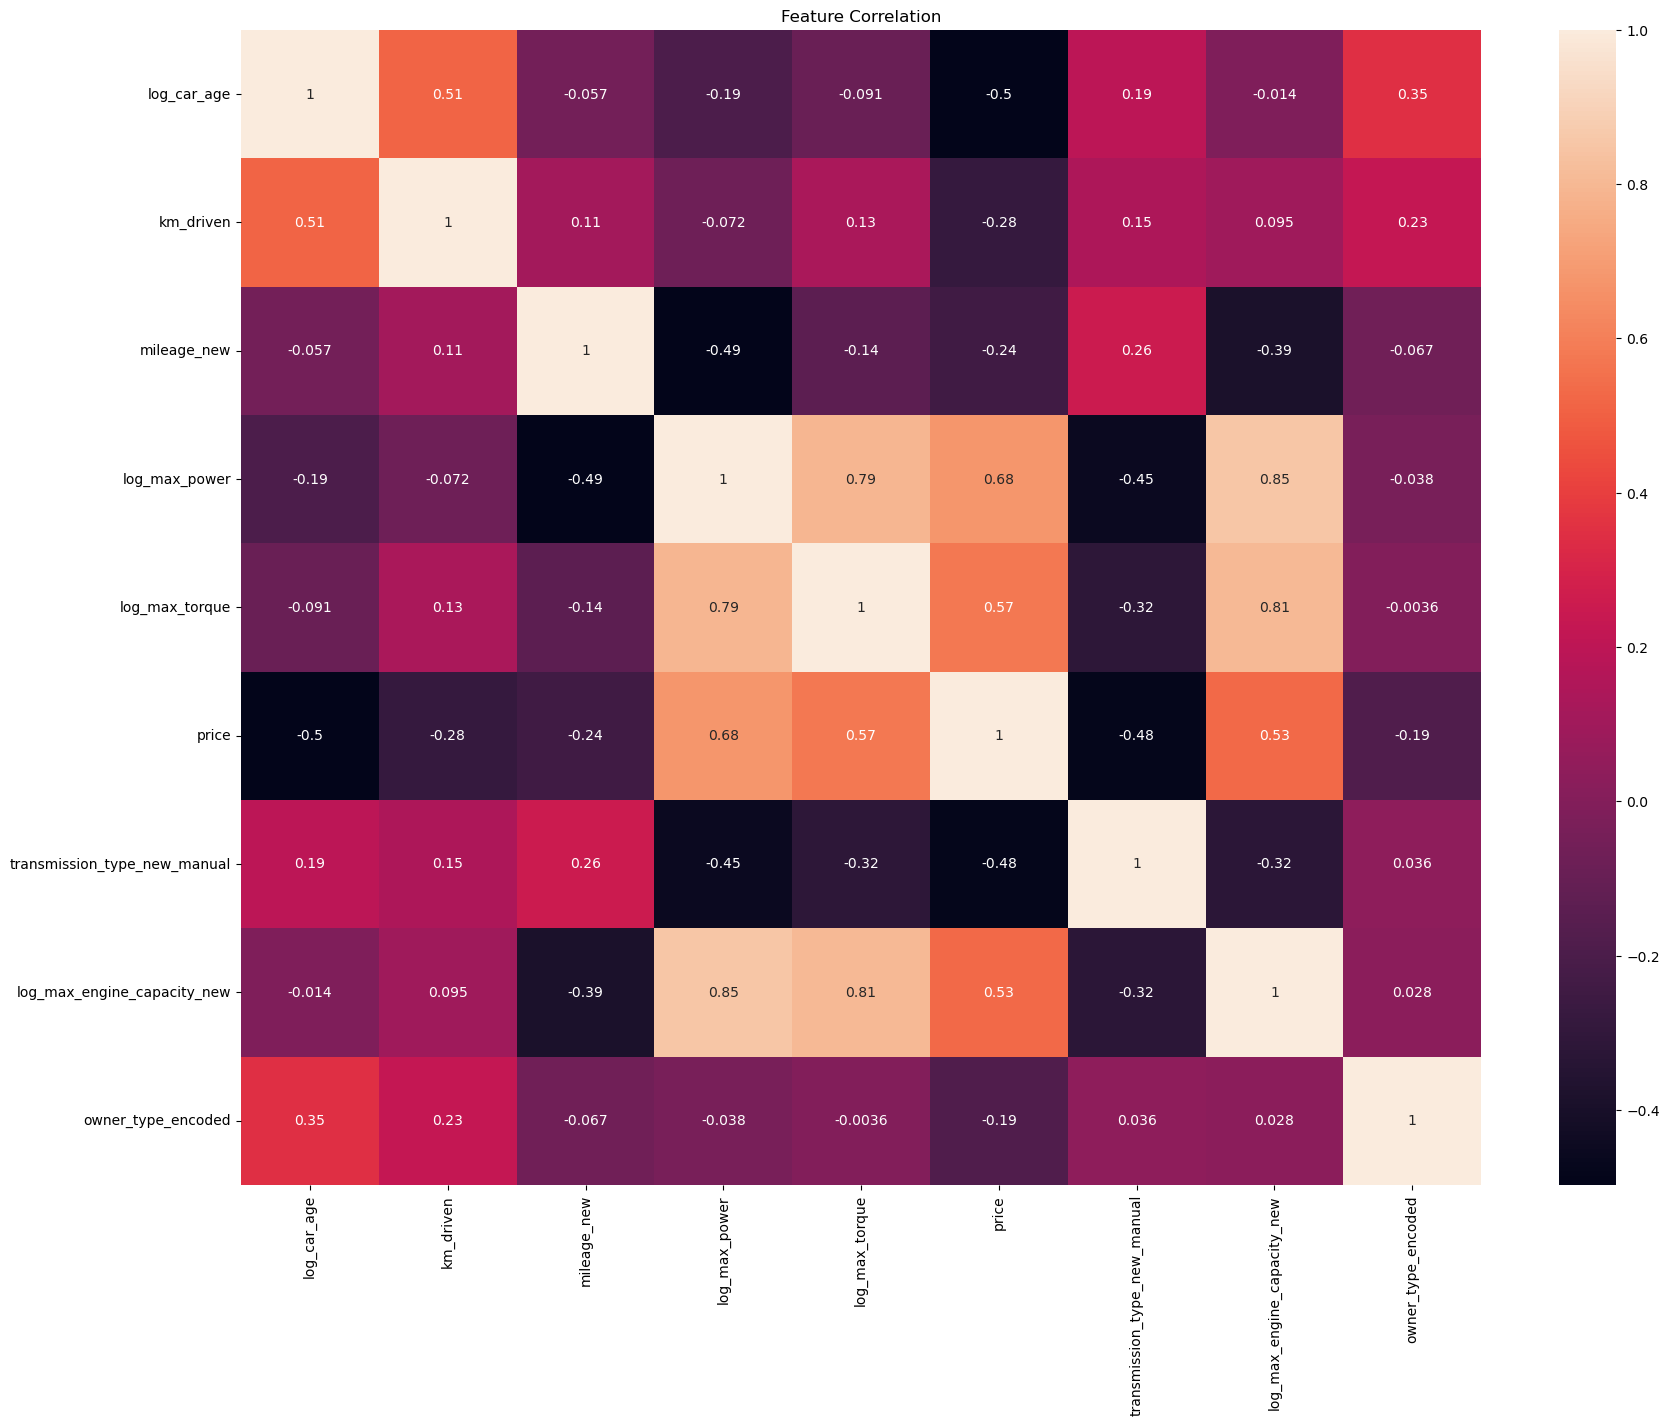

In [17]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(20, 15))

sns.heatmap(df[[
"log_car_age", "km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
    "transmission_type_new_manual", "log_max_engine_capacity_new", "owner_type_encoded"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

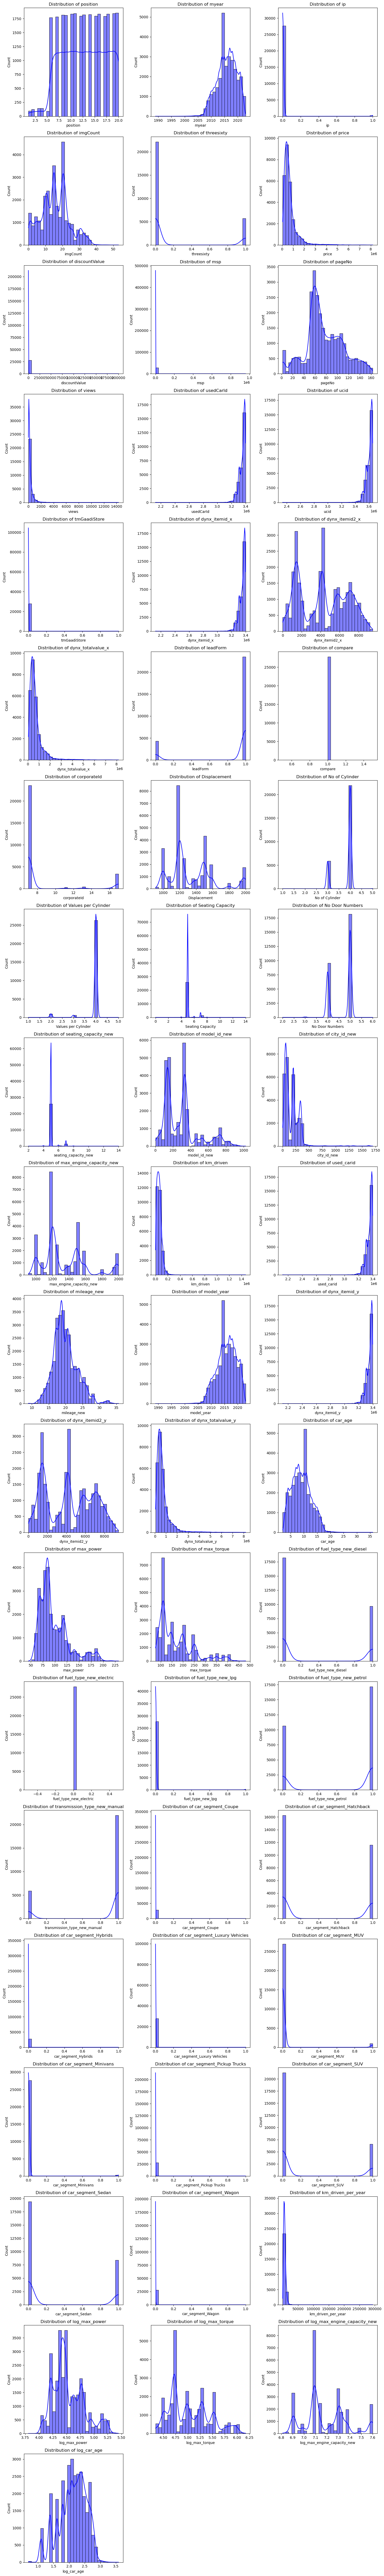

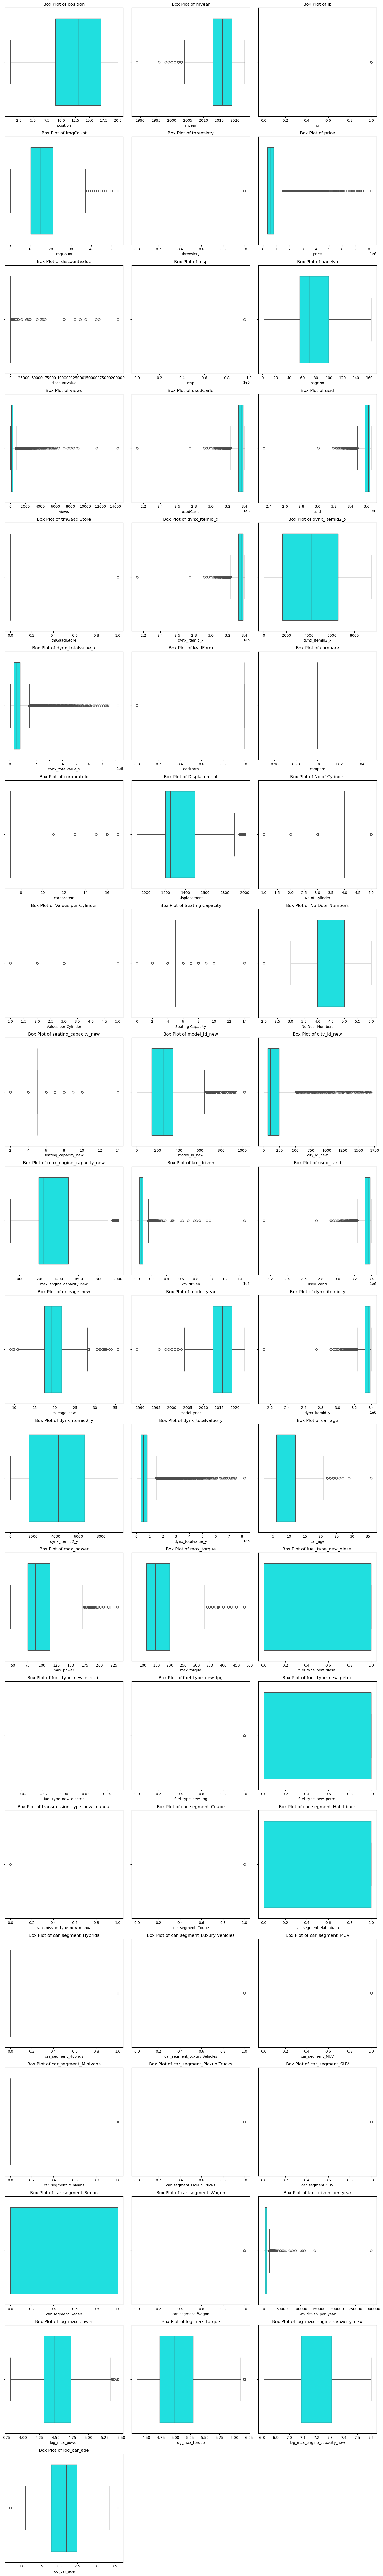

In [18]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
numerical_columns = df.select_dtypes(include=['int', 'float', 'bool']).columns.tolist()

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(512, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model.summary()
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,985 (726.50 KB)

 Trainable params: 185,985 (726.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train with `fit`, and display the error graph.
history = model.fit(X_train, y_train, epochs=60,validation_data=(X_val, y_val))

# Plot training history
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

Epoch 1/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 103357912.0000 - mae: 2599.1323 - val_loss: 131.0190 - val_mae: 11.4236
Epoch 2/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2356.4565 - mae: 11.7444 - val_loss: 46.0442 - val_mae: 6.7472
Epoch 3/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2031.6434 - mae: 6.1160 - val_loss: 0.5204 - val_mae: 0.5550
Epoch 4/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2909.2039 - mae: 1.8996 - val_loss: 0.5352 - val_mae: 0.5662
Epoch 5/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2323.6433 - mae: 1.6254 - val_loss: 0.5230 - val_mae: 0.5561
Epoch 6/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 432.8559 - mae: 1.2042 - val_loss: 0.5287 - val_mae: 0.5596
Epoch 7/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 120.0176 - mae: 1.0334 - val_loss: 0.5503 - val_mae: 0.5761
Epoch 8/60
697/697 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 82.9971 - mae: 1.0298 - val_loss: 0.5436 - val_mae: 0.5717
Epoch 9/60
697/697 ━━━━

In [ ]:

from sklearn.metrics import mean_absolute_error

# Predict log(price)
y_pred_log = model.predict(X_test_scaled)

# Convert to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_test)  # If y_test was log-transformed

print(y_pred_log.tolist())
print(y_pred.tolist())
print(y_true.tolist())
# Calculate MAE on the original price scale
mae_real = mean_absolute_error(y_test, y_pred_log)

print(f"Test MAE (real price): ₹{mae_real:,.0f}")

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[87.91333770751953], [195.56234741210938], [177.96487426757812], [189.42620849609375], [167.51829528808594], [160.6403045654297], [155.5596466064453], [161.78993225097656], [153.47129821777344], [126.53081512451172], [152.57484436035156], [61.38032913208008], [138.37498474121094], [104.6076431274414], [83.40225982666016], [154.2066192626953], [151.30113220214844], [209.49920654296875], [152.7275848388672], [47.99886703491211], [159.41326904296875], [60.4928092956543], [104.1261978149414], [267.2057189941406], [157.84141540527344], [224.26353454589844], [147.63787841796875], [168.3186798095703], [154.2355499267578], [161.2357940673828], [144.8368682861328], [111.2758560180664], [152.73922729492188], [124.1874771118164], [113.46480560302734], [150.04190063476562], [167.3977813720703], [175.09555053710938], [127.16107940673828], [132.61798095703125], [157.55172729492188], [48.52217483520508], [169.9200897216797], [80.88797760009766], [155.93989562

C:\Users\narut\AppData\Local\Temp\ipykernel_21856\3427633216.py:7: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(y_pred_log)
c:\Users\narut\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model.summary()
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,825 (179.00 KB)

 Trainable params: 45,825 (179.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 5083104804864.0000 - mae: 187049.8281 - val_loss: 5426679296.0000 - val_mae: 45833.3555
Epoch 2/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 112711172096.0000 - mae: 124380.0703 - val_loss: 535707264.0000 - val_mae: 10083.2402
Epoch 3/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2632286208000.0000 - mae: 135119.1406 - val_loss: 7382422528.0000 - val_mae: 56470.2930
Epoch 4/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 319419777024.0000 - mae: 121525.4141 - val_loss: 1662278400.0000 - val_mae: 30140.9434
Epoch 5/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 90933321728.0000 - mae: 126328.6250 - val_loss: 13095467008.0000 - val_mae: 74261.4453
Epoch 6/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 80620806144.0000 - mae: 119143.0859 - val_loss: 1297468416.0000 - val_mae: 28635.6934
Epoch 7/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 101750284288.0000 - mae: 117089.2109 - val_loss: 327513036

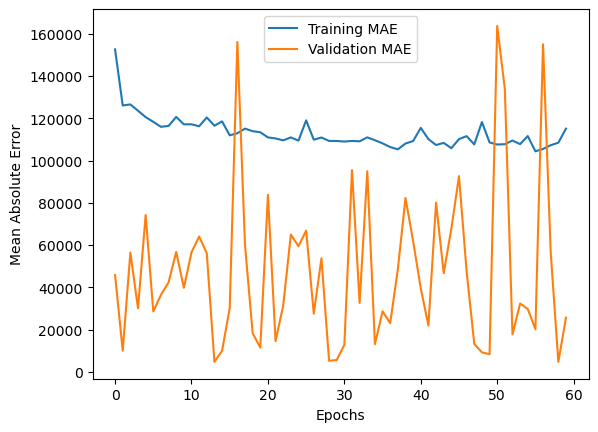

In [ ]:
# Train with `fit`, and display the error graph.
history = model.fit(X_train, y_train, epochs=60,validation_data=(X_val, y_val))

# Plot training history
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()